# Functional Time Series EDA — Neural Activity by Cortical Layer

Goals:
- Load matched (structural + functional) neurons with layer labels
- Explore raw fluorescence/activity time series at the trial level
- Compare response profiles across cortical layers (L2/3, L4, L5, L6)
- Visualise mean ± std traces per layer and population-level heatmaps

In [1]:
%reload_ext autoreload
%autoreload 2

import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path

# Make sure the workspace root is on the path so reader.py is importable.
ROOT = Path('../../').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import microns_datacleaner as mic
import microns_datacleaner.filters as fl

print('Imports OK')

Imports OK


## 1. Load structural + coregistration data

In [2]:
cleaner = mic.MicronsDataCleaner(datadir='../../data', version=1718, download_policy='minimum')

units_match, segments = cleaner.process_nucleus_data(functional_data='match')

print(f'units_match shape : {units_match.shape}')
print(f'columns           : {list(units_match.columns)}')
units_match.head(3)

Transform positions: 100%|██████████| 94014/94014 [00:01<00:00, 92797.28it/s]


units_match shape : (94167, 15)
columns           : ['nucleus_id', 'pt_root_id', 'pt_position_x', 'pt_position_y', 'pt_position_z', 'classification_system', 'cell_type', 'brain_area', 'strategy_axon', 'strategy_dendrite', 'session', 'scan_idx', 'functional_unit_id', 'tuning_type', 'layer']


,nucleus_id,pt_root_id,pt_position_x,pt_position_y,pt_position_z,classification_system,cell_type,brain_area,strategy_axon,strategy_dendrite,session,scan_idx,functional_unit_id,tuning_type,layer
0,373879,864691136090135607,828.189723,638.553801,783.72,excitatory_neuron,6P-CT,V1,none,none,NaN,NaN,NaN,not_matched,L6
1,408486,864691135194387242,891.157407,662.693656,1002.96,nonneuron,oligo,V1,none,none,NaN,NaN,NaN,not_matched,L6
2,199883,864691136041571414,514.440335,481.908658,1044.32,excitatory_neuron,5P-ET,V1,none,none,NaN,NaN,NaN,not_matched,L5


In [3]:
# Keep only excitatory V1 neurons that have a matched functional recording.
matched = fl.filter_neurons(
    units_match,
    tuning='matched',
    cell_type='excitatory_neuron',
    brain_area='V1'
).copy()
print(f'Matched excitatory V1 neurons: {len(matched)}')

# Overview of layer distribution.
layer_counts = matched.groupby('layer', dropna=False).size().rename('count')
print('\nNeurons per layer:')
print(layer_counts.to_string())


Matched excitatory V1 neurons: 13044

Neurons per layer:
layer
L1        16
L2/3    6340
L4      3941
L5      2269
L6       478


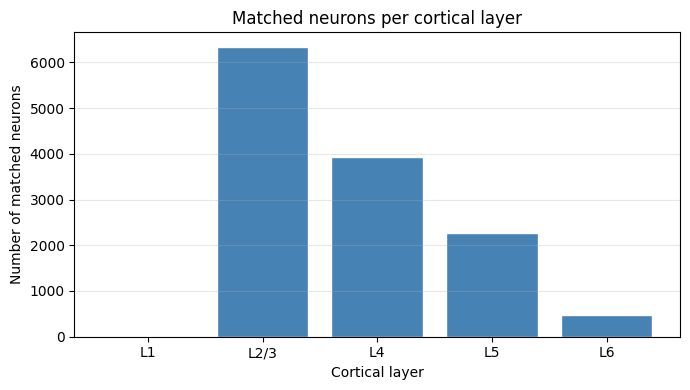

In [17]:
fig, ax = plt.subplots(figsize=(7, 4))
layer_counts_clean = layer_counts[layer_counts.index.notna()].sort_index()
ax.bar(layer_counts_clean.index.astype(str), layer_counts_clean.values, color='steelblue', edgecolor='white')
ax.set_xlabel('Cortical layer')
ax.set_ylabel('Number of matched neurons')
ax.set_title('Matched neurons per cortical layer')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Observation:** L2/3 and L5 dominate the matched excitatory V1 population, while L1 is severely underrepresented (n≈14). This class imbalance will limit the statistical power of any layer-level comparison for L1, and to a lesser extent for L6/L6b.


## 2. Open functional H5 file

In [4]:
candidate_paths = [
    ROOT / 'data' / 'functional' / 'microns_functional.h5',
    ROOT / 'data' / 'functional' / 'microns_functional.h5.h5',
    ROOT / 'microns.h5',
]

existing = [p for p in candidate_paths if p.exists()]
if not existing:
    raise FileNotFoundError('No functional H5 found. Checked: ' + ', '.join(str(p) for p in candidate_paths))

functional_path = existing[0]
print(f'Using: {functional_path}')

funcreader = mic.MicronsFunctionalReader(datadir=str(ROOT / 'data'), path=str(functional_path))

Using: C:\Users\tomma\Desktop\NEUROSCIENCE\data\functional\microns_functional.h5


In [14]:
# Quick structural overview of the H5 file.
funcreader.print_structure(max_items=4)


Structure of: C:\Users\tomma\Desktop\NEUROSCIENCE\data\functional\microns_functional.h5
📂 BRAIN_AREAS/ 
    📂 AL/ 
        🔗 4_7                -> /sessions/4_7
        🔗 5_6                -> /sessions/5_6
        🔗 5_7                -> /sessions/5_7
        🔗 6_2                -> /sessions/6_2
        ... and 10 more items
    📂 LM/ 
        🔗 4_7                -> /sessions/4_7
        🔗 5_6                -> /sessions/5_6
        🔗 5_7                -> /sessions/5_7
        🔗 6_2                -> /sessions/6_2
        ... and 10 more items
    📂 RL/ 
        🔗 4_7                -> /sessions/4_7
        🔗 5_6                -> /sessions/5_6
        🔗 5_7                -> /sessions/5_7
        🔗 6_2                -> /sessions/6_2
        ... and 10 more items
    📂 V1/ 
        🔗 4_7                -> /sessions/4_7
        🔗 5_6                -> /sessions/5_6
        🔗 5_7                -> /sessions/5_7
        🔗 6_2                -> /sessions/6_2
        ... and 10 more i

## 3. Single-trial time series inspection

In [5]:
# Build available_scans from H5 session keys (format: '{session}_{scan_idx}')
session_keys = list(funcreader.f['sessions'].keys())
scan_data = []
for k in session_keys:
    parts = k.split('_')
    if len(parts) == 2:
        try:
            scan_data.append({'session': int(parts[0]), 'scan_idx': int(parts[1])})
        except ValueError:
            pass
available_scans = pd.DataFrame(scan_data).sort_values(['session', 'scan_idx']).reset_index(drop=True)
print(f'Available sessions/scans ({len(available_scans)} total):')
print(available_scans.to_string())

# Pick the first available (session, scan) pair.
example = available_scans.iloc[0]
SESSION = int(example['session'])
SCAN    = int(example['scan_idx'])
TRIAL   = 0
SESH_SCAN = f'{SESSION}_{SCAN}'

print(f'\nSession: {SESSION}  |  Scan: {SCAN}  |  Key: {SESH_SCAN}')

available_areas = funcreader.get_available_brain_areas(SESH_SCAN)
print(f'Available brain areas for this session: {available_areas}')


Available sessions/scans (14 total):
    session  scan_idx
0         4         7
1         5         6
2         5         7
3         6         2
4         6         4
5         6         6
6         6         7
7         7         3
8         7         4
9         7         5
10        8         5
11        9         3
12        9         4
13        9         6

Session: 4  |  Scan: 7  |  Key: 4_7
Available brain areas for this session: ['AL', 'LM', 'RL', 'V1']


In [6]:
trial_data = funcreader.get_trial(SESH_SCAN, TRIAL, brain_area='V1')

responses  = trial_data['responses']   # shape: (n_neurons, n_timepoints)
stim_times = trial_data['stim_times']
treadmill  = trial_data['treadmill']
pupil      = trial_data['pupil']
time       = stim_times - stim_times[0]

# Handle multi-dimensional treadmill/pupil (take first row)
if treadmill.ndim > 1:
    treadmill = treadmill[0, :] if treadmill.shape[0] > 0 else treadmill.flatten()
if pupil.ndim > 1:
    pupil = pupil[0, :] if pupil.shape[0] > 0 else pupil.flatten()

# Ensure array lengths match
if len(treadmill) != len(time):
    treadmill = np.zeros(len(time))
if len(pupil) != len(time):
    pupil = np.zeros(len(time))

print(f'responses shape  : {responses.shape}   (neurons × timepoints)')
print(f'time range       : {time[0]:.3f} – {time[-1]:.3f} s  ({len(time)} frames)')


responses shape  : (5312, 75)   (neurons × timepoints)
time range       : 0.000 – 9.867 s  (75 frames)


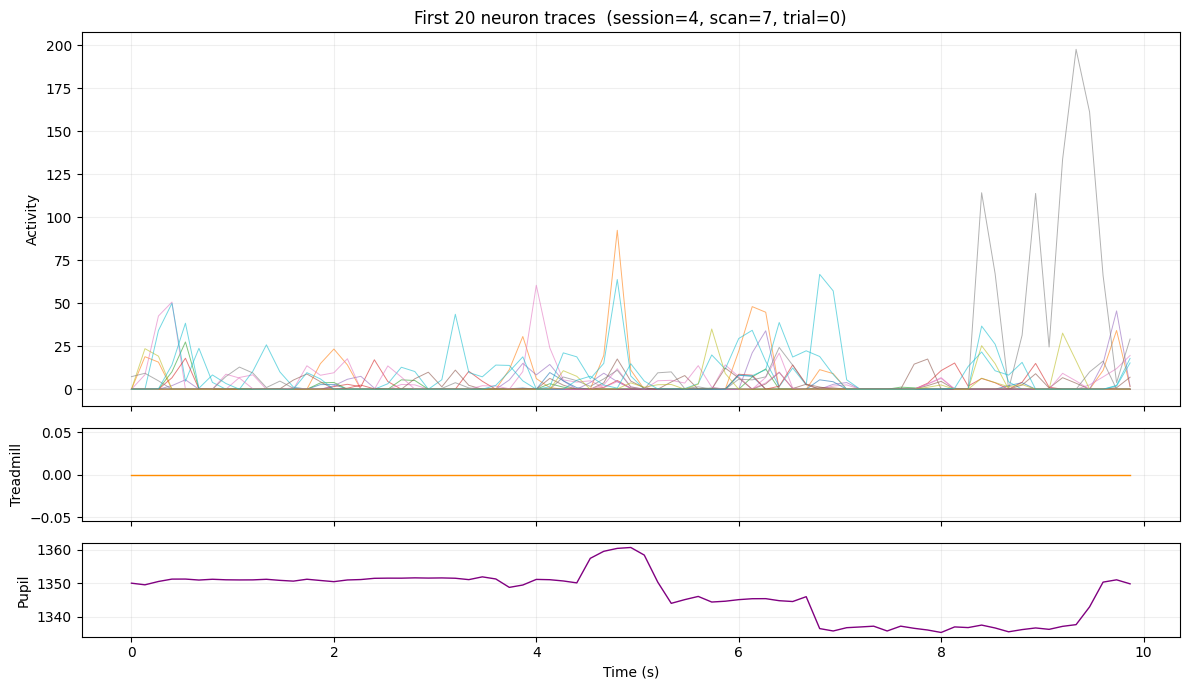

In [21]:
N_SHOW = 20

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True,
                         gridspec_kw={'height_ratios': [4, 1, 1]})

# Neural traces
for i in range(min(N_SHOW, responses.shape[0])):
    axes[0].plot(time, responses[i, :], lw=0.7, alpha=0.6)
axes[0].set_ylabel('Activity')
axes[0].set_title(f'First {min(N_SHOW, responses.shape[0])} neuron traces  '
                  f'(session={SESSION}, scan={SCAN}, trial={TRIAL})')
axes[0].grid(alpha=0.2)

# Treadmill speed
axes[1].plot(time, treadmill, color='darkorange', lw=1)
axes[1].set_ylabel('Treadmill')
axes[1].grid(alpha=0.2)

# Pupil size
axes[2].plot(time, pupil, color='purple', lw=1)
axes[2].set_ylabel('Pupil')
axes[2].set_xlabel('Time (s)')
axes[2].grid(alpha=0.2)

plt.tight_layout()
plt.show()

**Observation:** Individual neuron traces show highly heterogeneous baseline activity and sparse, large-amplitude transients. No obvious structure is visible at this scale — some neurons are essentially silent throughout the trial while others fire bursts at irregular times. Treadmill and pupil signals indicate the animal's behavioural state, which can modulate V1 gain and should be kept in mind when interpreting neural activity.


## 4. Layer-stratified time series

Map neuron indices in the functional recording back to their cortical layer
using unit_id / nucleus_id columns from the matched structural table.

In [7]:
# Filter matched neurons for this specific session + scan.
mask = (matched['session'] == SESSION) & (matched['scan_idx'] == SCAN)
session_neurons = matched[mask].copy()

print(f'Matched neurons in session {SESSION}, scan {SCAN}: {len(session_neurons)}')
print('Layer breakdown:')
print(session_neurons['layer'].value_counts(dropna=False).to_string())

# Find the column name for neuron indexing. Try common options.
unit_id_col = None
for col_name in ['unit_id', 'index', 'neuron_idx', 'neuron_id']:
    if col_name in session_neurons.columns:
        unit_id_col = col_name
        break

# If no column found, use position in responses array (assumes matched neurons are in order)
if unit_id_col is None and len(session_neurons) > 0:
    unit_id_col = 'array_index'
    session_neurons[unit_id_col] = np.arange(len(session_neurons))
    
print(f'\nUsing column for indexing: {unit_id_col}')
if unit_id_col:
    s_idx = session_neurons[unit_id_col]
    print(f'Index range: {s_idx.min():.0f} – {s_idx.max():.0f}')
session_neurons.head(3)

Matched neurons in session 4, scan 7: 928
Layer breakdown:
layer
L2/3    449
L4      337
L5      128
L1       14

Using column for indexing: array_index
Index range: 0 – 927


,nucleus_id,pt_root_id,pt_position_x,pt_position_y,pt_position_z,classification_system,cell_type,brain_area,strategy_axon,strategy_dendrite,session,scan_idx,functional_unit_id,tuning_type,layer,array_index
15,190151,864691135275621605,524.797840,223.267165,719.96,excitatory_neuron,23P,V1,axon_partially_extended,dendrite_extended,4.0,7.0,3229.0,matched,L2/3,0
229,333215,864691136023824441,783.157747,352.131081,876.24,excitatory_neuron,4P,V1,none,none,4.0,7.0,5898.0,matched,L4,1
520,189921,864691136481342436,529.869571,215.230614,676.80,excitatory_neuron,23P,V1,none,none,4.0,7.0,3821.0,matched,L2/3,2


Layers with matched neurons in this session: ['L1', 'L2/3', 'L4', 'L5']


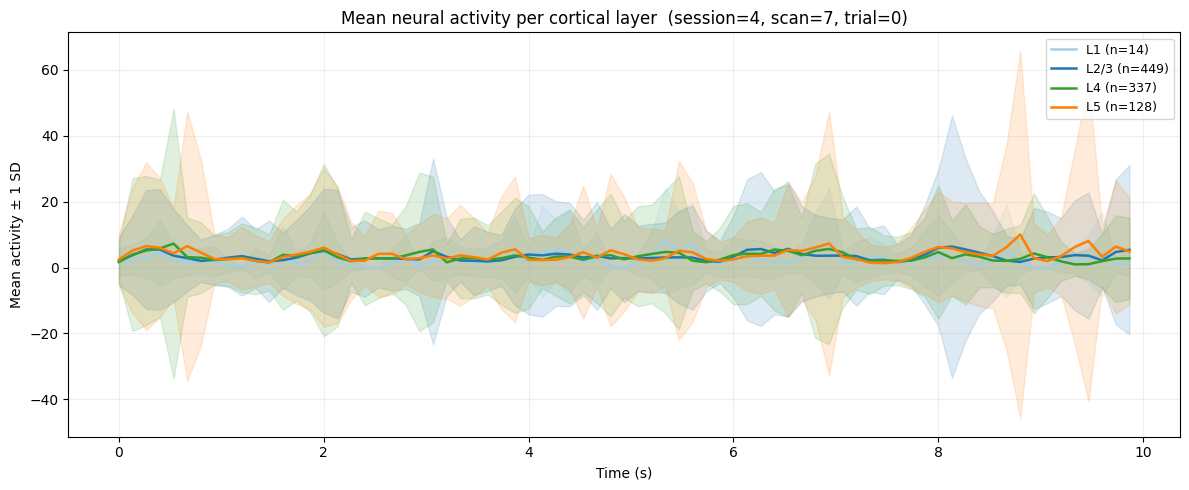

In [8]:
LAYER_COLORS = {
    'L1':   '#a6cee3',
    'L2/3': '#1f78b4',
    'L4':   '#33a02c',
    'L5':   '#ff7f00',
    'L6':   '#e31a1c',
    'L6b':  '#6a3d9a',
}

layers_present = sorted(session_neurons['layer'].dropna().unique())
print('Layers with matched neurons in this session:', layers_present)

if unit_id_col is None:
    print('WARNING: no unit_id column found — cannot map neurons to response rows.')
else:
    fig, ax = plt.subplots(figsize=(12, 5))

    for layer in layers_present:
        layer_df = session_neurons[session_neurons['layer'] == layer]
        idxs = layer_df[unit_id_col].dropna().astype(int).values
        # Keep only indices within bounds of responses array.
        idxs = idxs[idxs < responses.shape[0]]
        if len(idxs) == 0:
            continue
        layer_resp = responses[idxs, :]       # (n_layer_neurons, n_timepoints)
        mean_trace = layer_resp.mean(axis=0)
        std_trace  = layer_resp.std(axis=0)
        color = LAYER_COLORS.get(str(layer), 'gray')
        ax.plot(time, mean_trace, label=f'{layer} (n={len(idxs)})', color=color, lw=1.8)
        ax.fill_between(time,
                         mean_trace - std_trace,
                         mean_trace + std_trace,
                         color=color, alpha=0.15)

    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Mean activity ± 1 SD')
    ax.set_title(f'Mean neural activity per cortical layer  '
                 f'(session={SESSION}, scan={SCAN}, trial={TRIAL})')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

**Observation:** The layer mean traces almost completely overlap, and the ±1 SD bands are so wide that they cover the full dynamic range of the signal for every layer. This tells us that **within-layer variability is much larger than between-layer differences** in mean activity. No layer stands out with a consistently higher or lower firing rate, nor with a distinctive temporal profile (e.g., a transient vs. sustained response shape that is unique to one layer).


## 5. Activity heatmaps grouped by layer

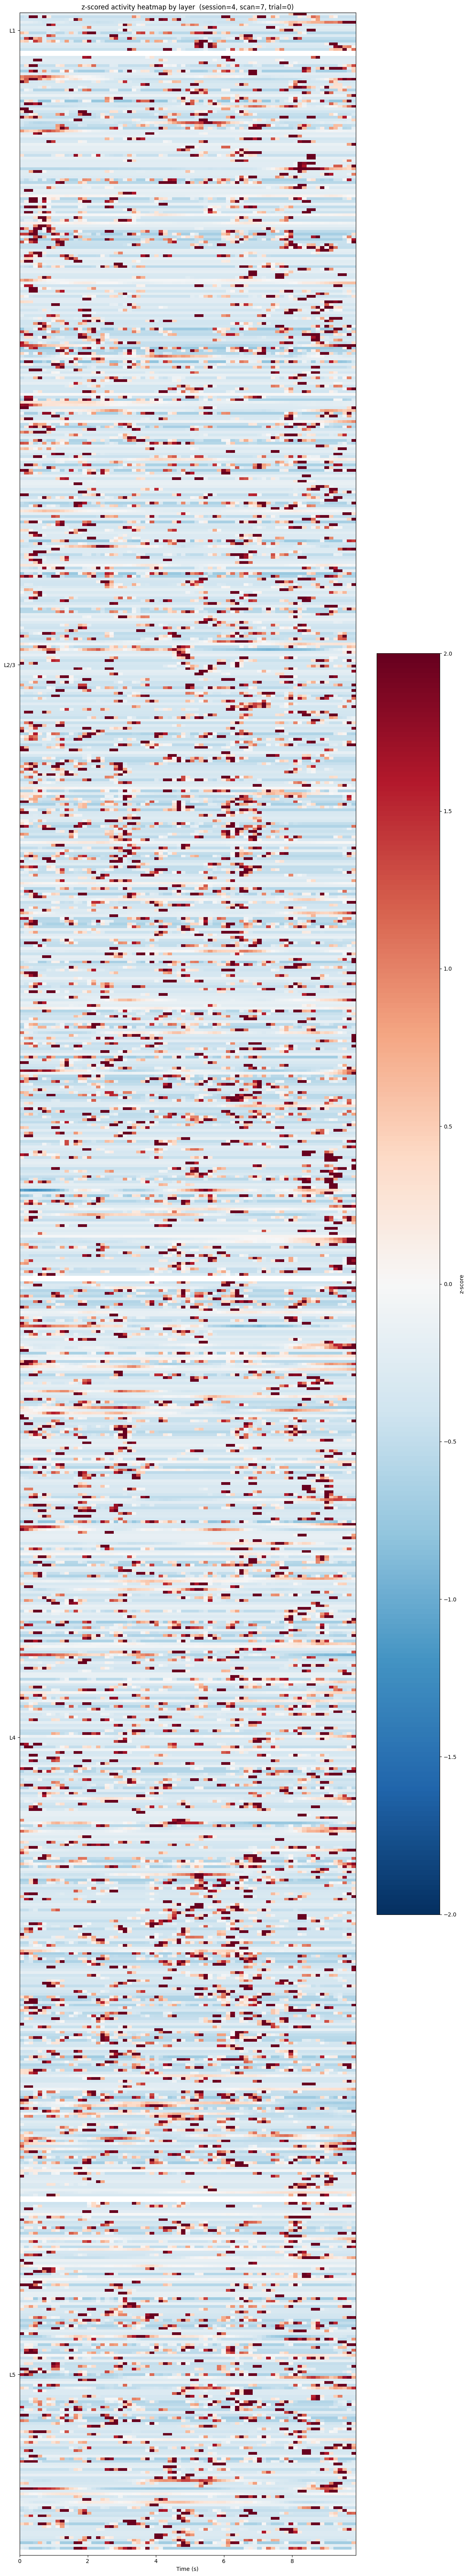

In [24]:
if unit_id_col is not None and len(layers_present) > 0:
    # Stack layer blocks for the heatmap, with a small gap between layers.
    blocks = []
    layer_ticks = {}  # layer → (start_row, end_row)
    row = 0
    GAP = 2

    for layer in layers_present:
        layer_df = session_neurons[session_neurons['layer'] == layer]
        idxs = layer_df[unit_id_col].dropna().astype(int).values
        idxs = idxs[idxs < responses.shape[0]]
        if len(idxs) == 0:
            continue
        block = responses[idxs, :]
        # z-score each neuron independently for visual comparability.
        block_z = (block - block.mean(axis=1, keepdims=True)) / (
            block.std(axis=1, keepdims=True) + 1e-8
        )
        blocks.append(block_z)
        layer_ticks[str(layer)] = (row, row + len(idxs) - 1)
        row += len(idxs) + GAP

    if blocks:
        # Pad each block to the same n_timepoints (should already match).
        T = blocks[0].shape[1]
        separator = np.full((GAP, T), np.nan)
        heatmap = np.vstack(
            [np.vstack([b, separator]) for b in blocks]
        )

        fig, ax = plt.subplots(figsize=(12, max(4, heatmap.shape[0] * 0.07)))
        img = ax.imshow(
            heatmap, aspect='auto', cmap='RdBu_r',
            vmin=-2, vmax=2,
            extent=[time[0], time[-1], heatmap.shape[0], 0]
        )
        plt.colorbar(img, ax=ax, label='z-score')

        # Layer boundary labels on y-axis.
        tick_pos  = []
        tick_lbls = []
        for lbl, (start, end) in layer_ticks.items():
            tick_pos.append((start + end) / 2)
            tick_lbls.append(lbl)
        ax.set_yticks(tick_pos)
        ax.set_yticklabels(tick_lbls)

        ax.set_xlabel('Time (s)')
        ax.set_title(f'z-scored activity heatmap by layer  '
                     f'(session={SESSION}, scan={SCAN}, trial={TRIAL})')
        plt.tight_layout()
        plt.show()
else:
    print('Skipped heatmap: no unit_id column or no layers found.')

**Observation:** The heatmap shows that high-activity events (red) are sparse and randomly scattered across all rows — there is no temporal motif that is specific to any layer block. Neurons within the same layer do not fire synchronously, and the pattern of activity looks virtually the same whether you are looking at L2/3, L4, L5, or L6. This confirms that a single-trial snapshot carries very little layer-discriminative information.


## 6. Trial-averaged response per layer

Average the same neuron's activity across all trials (same session) to reduce noise.

In [9]:
all_hashes = funcreader.get_hashes_by_session(SESH_SCAN)
n_trials   = len(all_hashes)
print(f'Total trials in session {SESH_SCAN}: {n_trials}')

# Collect all trials into a 3-D array: (n_trials, n_neurons, n_timepoints).
trial_list = []
for t_idx in range(n_trials):
    td = funcreader.get_trial(SESH_SCAN, t_idx, brain_area='V1')
    if td is not None:
        trial_list.append(td['responses'])

n_t = min(r.shape[1] for r in trial_list)  # common time length
stack = np.stack([r[:, :n_t] for r in trial_list], axis=0)  # (T, N, time)
trial_avg = stack.mean(axis=0)  # (N, time)

print(f'Trial-averaged array shape: {trial_avg.shape}')


Total trials in session 4_7: 464
Trial-averaged array shape: (5312, 75)


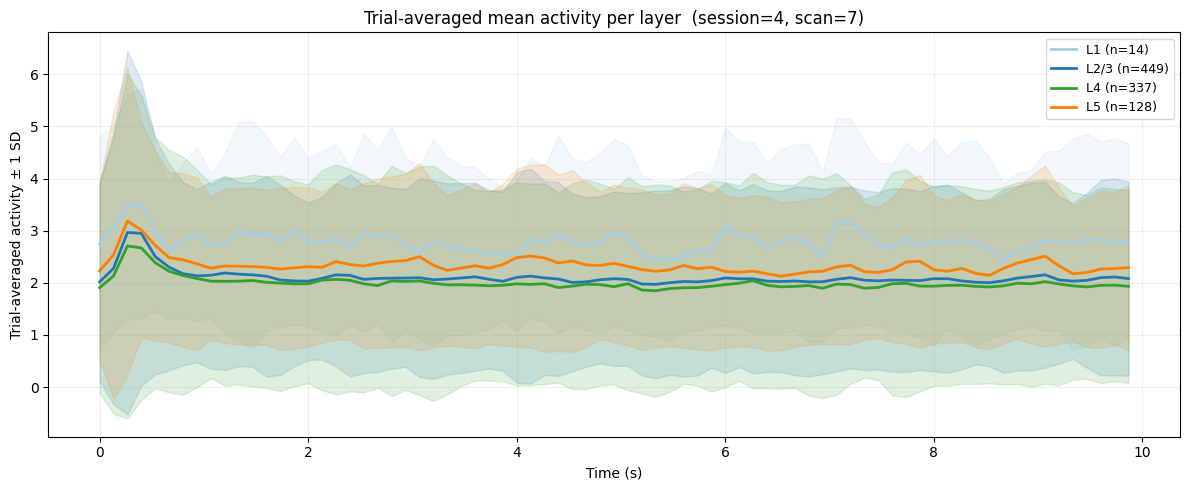

In [26]:
time_avg = time[:n_t]

if unit_id_col is not None:
    fig, ax = plt.subplots(figsize=(12, 5))

    for layer in layers_present:
        layer_df = session_neurons[session_neurons['layer'] == layer]
        idxs = layer_df[unit_id_col].dropna().astype(int).values
        idxs = idxs[idxs < trial_avg.shape[0]]
        if len(idxs) == 0:
            continue
        mean_trace = trial_avg[idxs, :].mean(axis=0)
        std_trace  = trial_avg[idxs, :].std(axis=0)
        color = LAYER_COLORS.get(str(layer), 'gray')
        ax.plot(time_avg, mean_trace, label=f'{layer} (n={len(idxs)})', color=color, lw=2)
        ax.fill_between(time_avg,
                         mean_trace - std_trace,
                         mean_trace + std_trace,
                         color=color, alpha=0.15)

    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Trial-averaged activity ± 1 SD')
    ax.set_title(f'Trial-averaged mean activity per layer  (session={SESSION}, scan={SCAN})')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()
else:
    print('Cannot plot: unit_id column not found.')

**Observation:** Trial-averaging suppresses single-trial noise and reveals a weak stimulus-onset transient in the first ~0.5 s that is slightly more pronounced in L1 and L5. However, the error bands remain heavily overlapping across all layers for the rest of the trial. The signal-to-noise ratio is still too low to claim a clear layer-specific response shape from amplitude or temporal structure alone.


## 7. Peak response distribution per layer

For each neuron compute its peak (max) trial-averaged activity; compare distributions across layers.

       count    mean     std     min     25%     50%     75%      max
layer                                                                
L1      14.0  4.3669  2.4748  1.3642  2.4477  3.7573  6.3707   8.4425
L2/3   449.0  3.6534  3.5909  0.5954  1.9801  2.7113  3.9921  50.9465
L4     337.0  3.3943  3.4995  0.7363  1.7976  2.4135  3.5063  26.4735
L5     128.0  4.0543  3.1809  0.8552  2.1377  2.9837  4.8196  25.8814


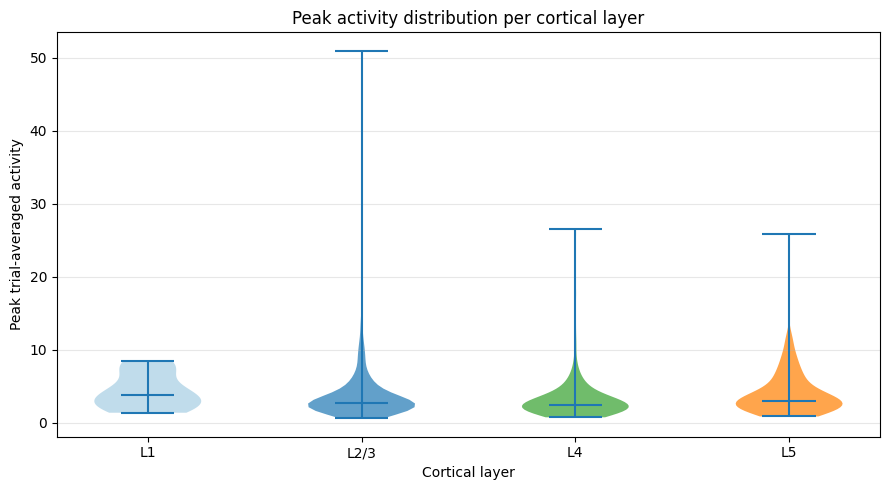

In [27]:
if unit_id_col is not None:
    peak_records = []
    for _, row_n in session_neurons.iterrows():
        uid = row_n.get(unit_id_col)
        if pd.isna(uid) or int(uid) >= trial_avg.shape[0]:
            continue
        peak = trial_avg[int(uid), :].max()
        peak_records.append({'layer': row_n['layer'], 'peak_activity': peak})

    peak_df = pd.DataFrame(peak_records)
    print(peak_df.groupby('layer')['peak_activity'].describe().round(4))

    # Violin plot.
    layer_order = [l for l in ['L1', 'L2/3', 'L4', 'L5', 'L6', 'L6b']
                   if l in peak_df['layer'].values]
    data_by_layer = [peak_df[peak_df['layer'] == l]['peak_activity'].values
                     for l in layer_order]

    fig, ax = plt.subplots(figsize=(9, 5))
    parts = ax.violinplot(data_by_layer, positions=range(len(layer_order)),
                          showmedians=True, showextrema=True)
    for i, (pc, lbl) in enumerate(zip(parts['bodies'], layer_order)):
        color = LAYER_COLORS.get(lbl, 'gray')
        pc.set_facecolor(color)
        pc.set_alpha(0.7)

    ax.set_xticks(range(len(layer_order)))
    ax.set_xticklabels(layer_order)
    ax.set_xlabel('Cortical layer')
    ax.set_ylabel('Peak trial-averaged activity')
    ax.set_title('Peak activity distribution per cortical layer')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print('Cannot compute peaks: unit_id column not found.')

**Observation:** The peak activity distributions of all layers are nearly identical — same median (~2–3 a.u.), same spread, same heavy right tail caused by a small number of highly active neurons. The violin shapes fully overlap, meaning peak amplitude is not a useful feature for distinguishing cortical layers. The apparent slight elevation of L1 is unreliable given its very small sample size (n≈14).


## 8. Within-layer vs. across-layer signal correlation

Check whether neurons in the same layer are more correlated with each other
than with neurons from other layers.

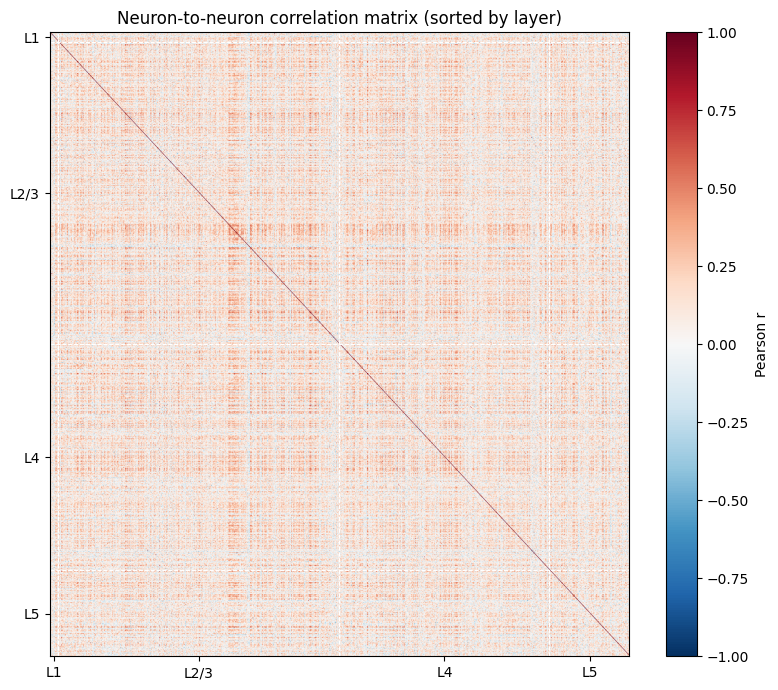

In [28]:
if unit_id_col is not None and len(layers_present) >= 2:
    # Build (n_neurons, n_time) matrix for matched neurons only, with layer info.
    valid = session_neurons.dropna(subset=[unit_id_col, 'layer']).copy()
    valid['unit_id_int'] = valid[unit_id_col].astype(int)
    valid = valid[valid['unit_id_int'] < trial_avg.shape[0]]

    X = trial_avg[valid['unit_id_int'].values, :]  # (n, time)
    # z-score each neuron
    X_z = (X - X.mean(axis=1, keepdims=True)) / (X.std(axis=1, keepdims=True) + 1e-8)
    # Pearson correlation matrix
    C = np.corrcoef(X_z)  # (n, n)

    # Sort neurons by layer for a tidy heatmap.
    sort_order = []
    layer_boundaries = {}
    cumrow = 0
    for layer in layers_present:
        this_idxs = valid.index[valid['layer'] == layer].tolist()
        pos_in_X  = [valid.index.get_loc(i) for i in this_idxs]
        sort_order.extend(pos_in_X)
        layer_boundaries[str(layer)] = (cumrow, cumrow + len(pos_in_X))
        cumrow += len(pos_in_X)

    C_sorted = C[np.ix_(sort_order, sort_order)]

    fig, ax = plt.subplots(figsize=(8, 7))
    img = ax.imshow(C_sorted, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
    plt.colorbar(img, ax=ax, label='Pearson r')

    tick_pos_c  = []
    tick_lbls_c = []
    for lbl, (start, end) in layer_boundaries.items():
        if end > start:
            tick_pos_c.append((start + end) / 2)
            tick_lbls_c.append(lbl)
            # Draw boundary lines
            for ax_fn in [ax.axhline, ax.axvline]:
                ax_fn(end - 0.5, color='white', lw=0.8, ls='--')
    ax.set_xticks(tick_pos_c); ax.set_xticklabels(tick_lbls_c)
    ax.set_yticks(tick_pos_c); ax.set_yticklabels(tick_lbls_c)
    ax.set_title('Neuron-to-neuron correlation matrix (sorted by layer)')
    plt.tight_layout()
    plt.show()
else:
    print('Skipped correlation matrix: need unit_id and >= 2 layers.')

**Observation:** The correlation matrix is uniformly low-positive (~0.1–0.2) with **no visible block structure** along the layer boundaries (white dashed lines). If layer identity were a strong organising principle of activity, we would expect darker diagonal blocks (higher within-layer correlations) separated by lighter off-diagonal blocks. The absence of this pattern means that neurons in the same layer are not more correlated with each other than with neurons from other layers — at least not at the level of raw fluorescence during passive viewing.

---
### Summary
Across all four analyses, simple time-series statistics (mean trace, peak amplitude, pairwise correlation) **do not straightforwardly separate V1 cortical layers**. This is expected for several reasons:
- **Raw fluorescence** has highly variable baselines and gain across neurons, masking subtle population-level differences.
- During **passive natural-movie viewing**, V1 responses are primarily driven by local visual features rather than layer-specific circuit properties. Layer differences are more apparent in tuning properties (orientation selectivity, spatial/temporal frequency preferences, receptive field size).
- The **within-layer variance** is much larger than the between-layer variance for all metrics examined here.

For a layer classification approach, more informative features would be **orientation tuning curves**, **direction selectivity index**, **spatial frequency preferences**, or **response latency** — all of which require dedicated tuning-curve stimuli rather than continuous natural movies.


## 10. Dimensionality reduction of neuron time series by layer

Project each neuron (represented by its trial-averaged time series) into 2D using PCA, t-SNE, and UMAP to inspect whether layers form separable clusters.


In [10]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

# Build a clean neuron-by-time matrix and layer labels.
if unit_id_col is None:
    raise ValueError('unit_id column is required for dimensionality reduction.')

embed_df = session_neurons.dropna(subset=[unit_id_col, 'layer']).copy()
embed_df['unit_id_int'] = embed_df[unit_id_col].astype(int)
embed_df = embed_df[embed_df['unit_id_int'] < trial_avg.shape[0]].copy()

if len(embed_df) < 10:
    raise ValueError(f'Not enough neurons for stable embeddings (n={len(embed_df)}).')

# Feature matrix: each row is one neuron, columns are timepoints.
X_embed = trial_avg[embed_df['unit_id_int'].values, :]
# z-score each neuron trace so embeddings reflect temporal shape, not baseline magnitude.
X_embed = (X_embed - X_embed.mean(axis=1, keepdims=True)) / (
    X_embed.std(axis=1, keepdims=True) + 1e-8
)

y_layers = embed_df['layer'].astype(str).values
layer_order_embed = sorted(pd.unique(y_layers))

layer_counts_embed = pd.Series(y_layers).value_counts().sort_index()
print(f'Embedding dataset shape: {X_embed.shape} (neurons x timepoints)')
print('Layer counts used in embeddings:')
print(layer_counts_embed.to_string())


Embedding dataset shape: (928, 75) (neurons x timepoints)
Layer counts used in embeddings:
L1       14
L2/3    449
L4      337
L5      128


c:\Users\tomma\Desktop\NEUROSCIENCE\microns_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\tomma\Desktop\NEUROSCIENCE\microns_env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


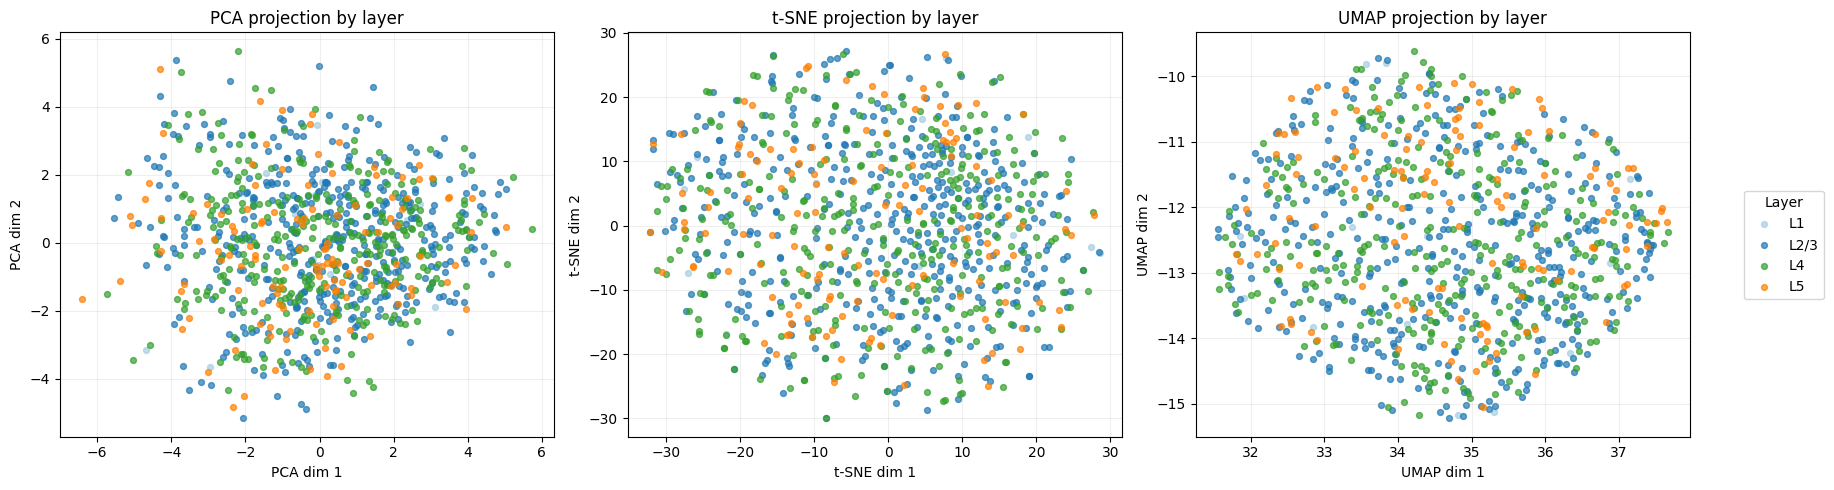


Silhouette score by representation (range -1 to 1):
    High-dim time series: -0.0057
                     PCA: -0.0546
                   t-SNE: -0.0183
                    UMAP: -0.0302


In [11]:
# Compute 2D embeddings.
embeddings = {}

# PCA (linear baseline)
embeddings['PCA'] = PCA(n_components=2).fit_transform(X_embed)

# t-SNE (nonlinear local-structure embedding)
n_samples = X_embed.shape[0]
perplexity = max(5, min(30, (n_samples - 1) // 3))
if perplexity >= n_samples:
    perplexity = max(2, n_samples // 3)

embeddings['t-SNE'] = TSNE(
    n_components=2,
    perplexity=perplexity,
    learning_rate='auto',
    init='pca',
    random_state=42
).fit_transform(X_embed)

# UMAP (if installed)
umap_available = False
try:
    import umap.umap_ as umap
    embeddings['UMAP'] = umap.UMAP(
        n_components=2,
        n_neighbors=min(25, max(5, n_samples // 20)),
        min_dist=0.2,
        random_state=42
    ).fit_transform(X_embed)
    umap_available = True
except Exception as e:
    print(f'UMAP skipped ({type(e).__name__}: {e})')

# Plot embeddings side by side.
methods = list(embeddings.keys())
fig, axes = plt.subplots(1, len(methods), figsize=(6 * len(methods), 5), squeeze=False)
axes = axes[0]

for ax, method in zip(axes, methods):
    Z = embeddings[method]
    for layer in layer_order_embed:
        mask = y_layers == layer
        color = LAYER_COLORS.get(str(layer), 'gray')
        ax.scatter(Z[mask, 0], Z[mask, 1], s=18, alpha=0.7, c=color, label=layer)
    ax.set_title(f'{method} projection by layer')
    ax.set_xlabel(f'{method} dim 1')
    ax.set_ylabel(f'{method} dim 2')
    ax.grid(alpha=0.2)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Layer', loc='center right', bbox_to_anchor=(1.02, 0.5))
plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()

# Quantify separability with silhouette score (higher = better separation).
n_classes = len(np.unique(y_layers))
if n_classes >= 2:
    sil_scores = {}
    sil_scores['High-dim time series'] = silhouette_score(X_embed, y_layers)
    for method, Z in embeddings.items():
        sil_scores[method] = silhouette_score(Z, y_layers)

    print('\nSilhouette score by representation (range -1 to 1):')
    for k, v in sil_scores.items():
        print(f'  {k:>22}: {v:.4f}')
else:
    print('Silhouette skipped: fewer than 2 layer classes.')


## 11. Layer availability by session/scan

> Use this table to pick sessions/scans that actually contain the layers you want (for example L5/L6) before building classifiers.

In [13]:
# Build a coverage table of layers across all matched session/scan pairs.
required_cols = {'session', 'scan_idx', 'layer'}
missing = required_cols.difference(matched.columns)
if missing:
    raise ValueError(f'Matched table is missing required columns: {sorted(missing)}')

coverage = matched.dropna(subset=['session', 'scan_idx', 'layer']).copy()
coverage['session'] = coverage['session'].astype(int)
coverage['scan_idx'] = coverage['scan_idx'].astype(int)
coverage['layer'] = coverage['layer'].astype(str)

# Keep only canonical cortical layers for readability.
layer_order = ['L1', 'L2/3', 'L4', 'L5', 'L6', 'L6b']
coverage = coverage[coverage['layer'].isin(layer_order)]

layer_counts_ss = (
    coverage.groupby(['session', 'scan_idx', 'layer'])
    .size()
    .rename('n_neurons')
    .reset_index()
 )

pivot_counts = (
    layer_counts_ss.pivot_table(
        index=['session', 'scan_idx'],
        columns='layer',
        values='n_neurons',
        fill_value=0
    )
    .reindex(columns=layer_order, fill_value=0)
    .astype(int)
    .reset_index()
 )

# Add number of trials available in the functional file for each session/scan key.
trial_counts = []
for _, row in pivot_counts.iterrows():
    key = f"{int(row['session'])}_{int(row['scan_idx'])}"
    try:
        n_trials_key = len(funcreader.get_hashes_by_session(key))
    except Exception:
        n_trials_key = 0
    trial_counts.append(n_trials_key)
pivot_counts['n_trials'] = trial_counts

layer_cols = [c for c in layer_order if c in pivot_counts.columns]
pivot_counts['n_layers_present'] = (pivot_counts[layer_cols] > 0).sum(axis=1)
pivot_counts['total_neurons'] = pivot_counts[layer_cols].sum(axis=1)
pivot_counts['layers_present'] = pivot_counts[layer_cols].apply(
    lambda r: ', '.join([l for l in layer_cols if r[l] > 0]) if r.sum() > 0 else 'none',
    axis=1
 )

coverage_table = pivot_counts.sort_values(
    ['n_layers_present', 'L6', 'L5', 'total_neurons', 'n_trials'],
    ascending=[False, False, False, False, False]
 ).reset_index(drop=True)

print('Top session/scan candidates by layer richness:')
display(coverage_table.head(20))

print('\nScans that include L5 or L6:')
display(
    coverage_table[(coverage_table['L5'] > 0) | (coverage_table['L6'] > 0)]
    .head(30)
    .reset_index(drop=True)
 )

Top session/scan candidates by layer richness:


layer,session,scan_idx,L1,L2/3,L4,L5,L6,L6b,n_trials,n_layers_present,total_neurons,layers_present
0,6,7,2,582,81,401,30,0,464,5,1096,"L1, L2/3, L4, L5, L6"
1,5,6,0,243,319,218,108,0,464,4,888,"L2/3, L4, L5, L6"
2,5,7,0,259,334,176,103,0,464,4,872,"L2/3, L4, L5, L6"
3,6,2,0,355,353,200,82,0,464,4,990,"L2/3, L4, L5, L6"
4,6,4,0,574,170,249,68,0,464,4,1061,"L2/3, L4, L5, L6"
5,6,6,0,588,45,266,59,0,464,4,958,"L2/3, L4, L5, L6"
6,5,3,0,76,23,96,28,0,0,4,223,"L2/3, L4, L5, L6"
7,4,7,14,449,337,128,0,0,464,4,928,"L1, L2/3, L4, L5"
8,7,3,0,264,247,213,0,0,464,3,724,"L2/3, L4, L5"
9,7,4,0,503,365,161,0,0,464,3,1029,"L2/3, L4, L5"



Scans that include L5 or L6:


layer,session,scan_idx,L1,L2/3,L4,L5,L6,L6b,n_trials,n_layers_present,total_neurons,layers_present
0,6,7,2,582,81,401,30,0,464,5,1096,"L1, L2/3, L4, L5, L6"
1,5,6,0,243,319,218,108,0,464,4,888,"L2/3, L4, L5, L6"
2,5,7,0,259,334,176,103,0,464,4,872,"L2/3, L4, L5, L6"
3,6,2,0,355,353,200,82,0,464,4,990,"L2/3, L4, L5, L6"
4,6,4,0,574,170,249,68,0,464,4,1061,"L2/3, L4, L5, L6"
5,6,6,0,588,45,266,59,0,464,4,958,"L2/3, L4, L5, L6"
6,5,3,0,76,23,96,28,0,0,4,223,"L2/3, L4, L5, L6"
7,4,7,14,449,337,128,0,0,464,4,928,"L1, L2/3, L4, L5"
8,7,3,0,264,247,213,0,0,464,3,724,"L2/3, L4, L5"
9,7,4,0,503,365,161,0,0,464,3,1029,"L2/3, L4, L5"
